# E2E LGBM-only Baseline

**1 Trial = 전처리 → 집계 → CLF → FS → REG → RMSE (모두 Optuna)**

- 전처리(cleaning/outlier/agg preset) + CLF HP + REG HP + FS top_k 전부 단일 Optuna study에서 동시 탐색
- CLF·REG 모두 LightGBM 고정 (앙상블 없음)
- 같은 전처리 파라미터 조합은 LRU 캐시로 재사용
- 기존 `pipeline_config` 스위치 및 실험 로깅 구조는 그대로 유지

## 1. 환경 설정 및 데이터 로드

In [ ]:
# ============================================================
# 환경 설정 + 데이터 로드 (Colab / Local 공통)
# ============================================================
import os, sys

try:
    import google.colab
    from google.colab import drive
    drive.mount('/content/drive')
    if not os.path.exists('/content/project/setup.py'):
        os.system('pip install -q gdown')
        os.system('gdown 1AD4PDBnDVjp-LSna6puB7qLnpBqB7j_I -O /content/code.zip')
        os.system('unzip -qo /content/code.zip -d /content/project')
        os.makedirs('/content/project/0_data', exist_ok=True)
        os.system('gdown 1yOUo0_wPLcuZBSJIK592b00YkSIlk4zO -O /content/project/0_data/dataset.zip')
        os.system('unzip -qo /content/project/0_data/dataset.zip -d /content/project/0_data')
        os.remove('/content/project/0_data/dataset.zip')
    if not os.path.exists('/content/project/2_preprocessing/cleaning.py'):
        os.system('gdown 1Rh0ByOS4Gama8XHuvY7KkOHo278H9YLr -O /content/preprocessing.zip')
        os.system('unzip -qo /content/preprocessing.zip -d /content/project')
    if not os.path.exists('/content/project/3_modeling/modules/e2e_hpo.py'):
        os.system('gdown 1Vrn5LBl611rWbag7d09LZH68_lfpu6wP -O /content/modules.zip')
        os.makedirs('/content/project/3_modeling/modules', exist_ok=True)
        os.system('unzip -qo /content/modules.zip -d /content/project/3_modeling/modules')
    sys.path.insert(0, '/content/project')
    %run /content/project/setup.py
except ImportError:
    %run ../../setup.py

# --- 기본 라이브러리 ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# --- 프로젝트 유틸 ---
from utils.config import PROJECT_ROOT, SEED, TARGET_COL, KEY_COL, OUTPUT_DIR
from utils.data import load_all, get_feat_cols, split_xs
from utils.evaluate import evaluate, rmse
from utils.experiment import log_experiment, check_exp_id, download_from_drive

# --- 3_modeling 모듈 ---
sys.path.insert(0, os.path.join(PROJECT_ROOT, '3_modeling'))
from modules.e2e_hpo import (
    run_e2e_optimization_with_pp,
    rerun_best_trial_with_pp,
)
from modules.search_space import (
    PP_CLEAN_CANDIDATES,
    PP_OUTLIER_CANDIDATES,
    AGG_PRESETS,
    PP_BINARIZE_CONFIG,               # ★ Binarize 비활성용
)

# ── 추가 전처리 비활성화 (1차 funnel 동일 조건) ──
PP_BINARIZE_CONFIG["apply"] = False   # ★ Binarize OFF (e2e_hpo 내부 자동 적용 방지)

# --- 데이터 로드 ---
xs, ys = load_all()
feat_cols = get_feat_cols(xs)
xs_dict = split_xs(xs)

print(f'Feature 수: {len(feat_cols)}')
print(f'Die 수: train={len(xs_dict["train"]):,}, '
      f'val={len(xs_dict["validation"]):,}, '
      f'test={len(xs_dict["test"]):,}')
print(f'Binarize: apply={PP_BINARIZE_CONFIG["apply"]}')

## 2. 실험 설정

모든 파라미터는 이 셀에서만 제어한다.
전처리 + CLF HP + REG HP + FS top_k 전부 Optuna가 한번에 탐색한다.

In [2]:
# ============================================================
# 실험 설정
# ============================================================

EXP_ID = '3-123-001'
EXP_TYPE = 'baseline + HPO'
EXP_MEMO = 'lgbm-only, log1p, y_train clip, val, test 비공개'

# ── 평가 스위치 (peeking 방지) ──
# EVAL_VAL : val RMSE 참고용 계산 (Optuna는 OOF RMSE로 최적화)
# EVAL_TEST: test RMSE 계산 — 최종 제출 직전에만 True
EVAL_VAL  = True
EVAL_TEST = True

# ── 결과물 저장 스위치 ──
# True : val/test 예측 CSV + Optuna study pickle 저장
# False: 파일 저장 생략 (실험 로그는 SAVE_OUTPUTS와 무관하게 항상 기록)
SAVE_OUTPUTS = False

# ── 사용자 식별 (빈칸 → 반드시 본인이 입력) ──
USER = 'jh'   # 예: 'jw', 'kim', 'lee', 'park'
assert USER, "USER를 지정해주세요 (예: USER = 'jw')"

# --- Google Drive 파일 ID ---
CSV_GDRIVE_ID = '1AR6ClYfaL6N_D1J_TGasnRC5O5oapn4N'   # 공용 experiments.csv 파일 ID (전원 동일)
# DB는 실험별 파일명이 달라져서 Drive 공유는 사용하지 않음 (Colab 종료 직전에 로컬로 다운로드)

# ── 경로 결정 (로컬/Colab 자동) ──
from utils.config import OUTPUT_DIR
EXP_SUBDIR = '1차 실험'          # ★ 실험 차수에 맞게 변경 ('1차 실험' / '2차 실험')
DB_PATH = os.path.join(OUTPUT_DIR, 'experiments', EXP_SUBDIR, f'optuna_{USER}_{EXP_ID}.db')
EXP_CSV_PATH = os.path.join(OUTPUT_DIR, 'experiments', EXP_SUBDIR, 'experiments.csv')
os.makedirs(os.path.dirname(DB_PATH), exist_ok=True)

LABEL_COL = 'label_bin'

# ── 타깃 변환 스위치 ──
# 'log1p'      : np.log1p 적용 → 예측 시 np.expm1 역변환
# 'yeo-johnson': PowerTransformer(yeo-johnson) 적용 → 예측 시 inverse_transform
# 'none'       : 변환 없이 원본 스케일 그대로 사용
TARGET_TRANSFORM = 'log1p'  # 'log1p' | 'yeo-johnson' | 'none'

# ── y_train 극단값(1.0) 클립 스위치 ──
# True : train y에서 max=1.0을 두 번째로 큰 값으로 클립 (모델 학습 입력에만 적용)
# False: 클립 없이 원본 그대로 사용
CLIP_Y_EXTREME = True

# --- 샘플링 (빠른 sanity check용) ---
sampling_params = dict(
    use_sampling=False,
    sample_frac=1.0,
)

# --- 웨이퍼맵 기반 사전 제외 feature ---
EXCLUDE_COLS = [
        'X124', 'X300', 'X301',
        # X441~X464
        'X441', 'X442', 'X443', 'X444', 'X445', 'X446', 'X447', 'X448',
        'X449', 'X450', 'X451', 'X452', 'X453', 'X454', 'X455', 'X456',
        'X457', 'X458', 'X459', 'X460', 'X461', 'X462', 'X463', 'X464',
        # X499~X506
        'X499', 'X500', 'X501', 'X502', 'X503', 'X504', 'X505', 'X506',
        # X658~X659, X671~X672, X674~X677, X680~X681, X683~X687
        'X658', 'X659', 'X671', 'X672',
        'X674', 'X675', 'X676', 'X677',
        'X680', 'X681',
        'X683', 'X684', 'X685', 'X686', 'X687',
        # 개별
        'X1041', 'X1074', 'X1078'
]

# ── 파이프라인 스위치 (pipeline_config) ──
# 기존 e2e_twostage와 동일 구조.
# 단, input_level='die' 고정 (전처리부터 돌리므로 die 필수)
pipeline_config = dict(
    input_level='die',      # 'die' 고정 (분류on일 시 변경 불가)
    run_clf=True,           # False → 분류 스킵, 회귀만
    clf_output='proba',     # 'proba' | 'binary'
    clf_filter=False,        # True → proba <= threshold 샘플을 회귀 학습에서 제외
    clf_optuna=True,        # False → CLF 기본 파라미터 (탐색 제외)
    run_fs=False,           # False → FS 스킵
    fs_optuna=False,        # False → 고정 top_k
    reg_level='position',   # 'unit' | 'position'
    reg_optuna=True,        # False → REG 기본 파라미터 (탐색 제외)
    zero_clip=True,         # True → 회귀 예측값 < threshold → 0 으로 clip (후처리)
)

# ── E2E HPO 설정 ──
# clf_model/reg_model는 'lgbm' 고정 (baseline)
e2e_params = dict(
    clf_model='lgbm',
    reg_model='lgbm',
    n_trials=20,
    n_folds=3,
    clf_early_stop=50,
    reg_early_stop=50,
    imbalance_method='scale_pos_weight',
    top_k_range=(50, 500),  # fs_optuna=True 일 때 탐색 범위
    top_k_fixed=200,        # fs_optuna=False 일 때 고정 값
    # clf_filter threshold 탐색 (clf_filter=True일 때만 탐색됨)
    clf_filter_threshold_range=(0.05, 0.5),  # step=0.05 → 후보 10개
    clf_filter_threshold_fixed=0.5,          # 폴백 값 (no-optuna 경로)
    # zero_clip threshold 탐색 (zero_clip=True일 때만 탐색됨)
    zero_clip_threshold_range=(0.002, 0.002),   # 0.002 고정 (탐색 범위로 설정하되 step=0 → 사실상 고정값)
    zero_clip_threshold_fixed=0.0,           # 폴백 값 (no-optuna 경로)
    clf_fixed={},           # CLF 고정 파라미터 (탐색 제외)
    reg_fixed={},           # REG 고정 파라미터 (예: {'objective': 'poisson'})
    pp_cache_size=10,       # 전처리 LRU 캐시 상한
)

# ── Rerun 설정 (best trial 재실행) ──
rerun_params = dict(
    mode='kfold',            # 'single' | 'kfold'
    n_folds=5,               # mode='kfold'일 때만 사용
    es_holdout=0.1,          # mode='single'일 때 ES용 holdout 비율
    clf_early_stop=100,
    reg_early_stop=100,
)

# --- 설정 출력 ---
print(f'실험번호: {EXP_ID} | {EXP_TYPE}')
print(f'USER: {USER}')
print(f'CLF: {e2e_params["clf_model"]} | REG: {e2e_params["reg_model"]}')
print(f'Trials: {e2e_params["n_trials"]} | Folds: {e2e_params["n_folds"]}')
print(f'Top-K: range={e2e_params["top_k_range"]}, fixed={e2e_params["top_k_fixed"]}')
print(f'CLF filter threshold: range={e2e_params["clf_filter_threshold_range"]}, fixed={e2e_params["clf_filter_threshold_fixed"]}')
print(f'Zero-clip threshold : range={e2e_params["zero_clip_threshold_range"]}, fixed={e2e_params["zero_clip_threshold_fixed"]}')
print(f'PP cache size: {e2e_params["pp_cache_size"]}')
print(f'샘플링: {"ON" if sampling_params["use_sampling"] else "OFF"} '
      f'(frac={sampling_params["sample_frac"]})')
print(f'Rerun: mode={rerun_params["mode"]}'
      + (f', n_folds={rerun_params["n_folds"]}' if rerun_params["mode"] == "kfold"
         else f', es_holdout={rerun_params["es_holdout"]}'))
print(f'제외 컬럼: {len(EXCLUDE_COLS)}개')
print(f'결과 저장: {"ON" if SAVE_OUTPUTS else "OFF"} (CSV + study pickle)')
print(f'타깃 변환: {TARGET_TRANSFORM}')
print(f'DB_PATH: {DB_PATH}')
print(f'\n── Pipeline Config ──')
for k, v in pipeline_config.items():
    print(f'  {k}: {v}')

# CSV만 Drive에서 내려받는다 (DB는 실험별 독립이므로 받지 않음)
download_from_drive(csv_gdrive_id=CSV_GDRIVE_ID)
check_exp_id(EXP_ID)

실험번호: 3-123-001 | baseline + HPO
USER: jh
CLF: lgbm | REG: lgbm
Trials: 20 | Folds: 3
Top-K: range=(50, 500), fixed=200
CLF filter threshold: range=(0.05, 0.5), fixed=0.5
Zero-clip threshold : range=(0.002, 0.002), fixed=0.0
PP cache size: 10
샘플링: OFF (frac=1.0)
Rerun: mode=kfold, n_folds=5
제외 컬럼: 53개
결과 저장: OFF (CSV + study pickle)
타깃 변환: log1p
DB_PATH: c:\Users\Dell5371\Desktop\기업연계프로젝트\4_output\experiments\optuna_jh_3-123-001.db

── Pipeline Config ──
  input_level: die
  run_clf: True
  clf_output: proba
  clf_filter: False
  clf_optuna: True
  run_fs: False
  fs_optuna: False
  reg_level: position
  reg_optuna: True
  zero_clip: True


## 3. 전처리 Search Space 확인 / 축소

`PP_CLEAN_CANDIDATES` / `PP_OUTLIER_CANDIDATES` / `AGG_PRESETS`는 `search_space.py`의 모듈 상수다.
아래 셀에서 dict/list 원소를 지우거나 수정하여 탐색 공간을 좁힐 수 있다.

**범위 조정 예시 (주석 해제해서 사용):**
```python
PP_CLEAN_CANDIDATES['imputation_method'] = ['median']       # spatial/knn 제외
PP_CLEAN_CANDIDATES['corr_threshold'] = [0.95]              # 상관 임계값 고정
PP_OUTLIER_CANDIDATES['method'] = ['winsorize', 'none']     # grubbs/lot_local 제외
```

In [3]:
# ── 현재 전처리 search space 확인 ──
print('── PP_CLEAN_CANDIDATES ──')
for k, v in PP_CLEAN_CANDIDATES.items():
    print(f'  {k}: {v}')
print('\n── PP_OUTLIER_CANDIDATES ──')
for k, v in PP_OUTLIER_CANDIDATES.items():
    print(f'  {k}: {v}')
print('\n── AGG_PRESETS ──')
for i, preset in enumerate(AGG_PRESETS):
    print(f'  [{i}] {preset}')

# ── 범위 축소 (필요 시 여기서 수정) ──
PP_CLEAN_CANDIDATES['imputation_method'] = ['spatial']
# PP_CLEAN_CANDIDATES['corr_threshold'] = [0.95]
PP_OUTLIER_CANDIDATES['method'] = ['winsorize']

# ── 탐색 공간 크기 추정 (grid 전개 시) ──
from functools import reduce
import operator
space_sizes = (
    [len(v) for v in PP_CLEAN_CANDIDATES.values()]
    + [len(v) for v in PP_OUTLIER_CANDIDATES.values()]
    + [len(AGG_PRESETS)]
)
total_grid = reduce(operator.mul, space_sizes, 1)
print(f'\n전처리 search space 크기 (grid): {total_grid:,}')

── PP_CLEAN_CANDIDATES ──
  const_threshold: [1e-06]
  missing_threshold: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
  remove_duplicates: [True]
  corr_threshold: [0.9, 0.94, 0.98]
  corr_keep_by: ['std', 'target_corr']
  add_indicator: [True, False]
  indicator_threshold: [0.01, 0.05, 0.1, 0.15, 0.2, 0.25]
  imputation_method: ['spatial']
  knn_neighbors: [3, 5, 10]
  spatial_max_dist: [1.0, 2.0, 3.0, 4.0, 5.0]
  post_impute_corr_threshold: [0.97, 0.98, 0.99]
  post_impute_corr_keep_by: ['std', 'target_corr']

── PP_OUTLIER_CANDIDATES ──
  method: ['winsorize']
  lower_pct: [0.0]
  upper_pct: [0.99]
  iqr_multiplier: [1.5, 3.0, 5.0]

── AGG_PRESETS ──
  [0] ['mean', 'std', 'range', 'min', 'max', 'median']
  [1] ['mean', 'std']
  [2] ['mean', 'std', 'median', 'range']
  [3] ['std', 'range', 'median']

전처리 search space 크기 (grid): 699,840


## 3.5 타겟 분포 시각화

[CLIP_Y_EXTREME] 1.0 → 0.097417 클립 | 클립된 샘플: 1개
[log1p] target_transform_fn 등록 (ys_input 은 원본 유지)


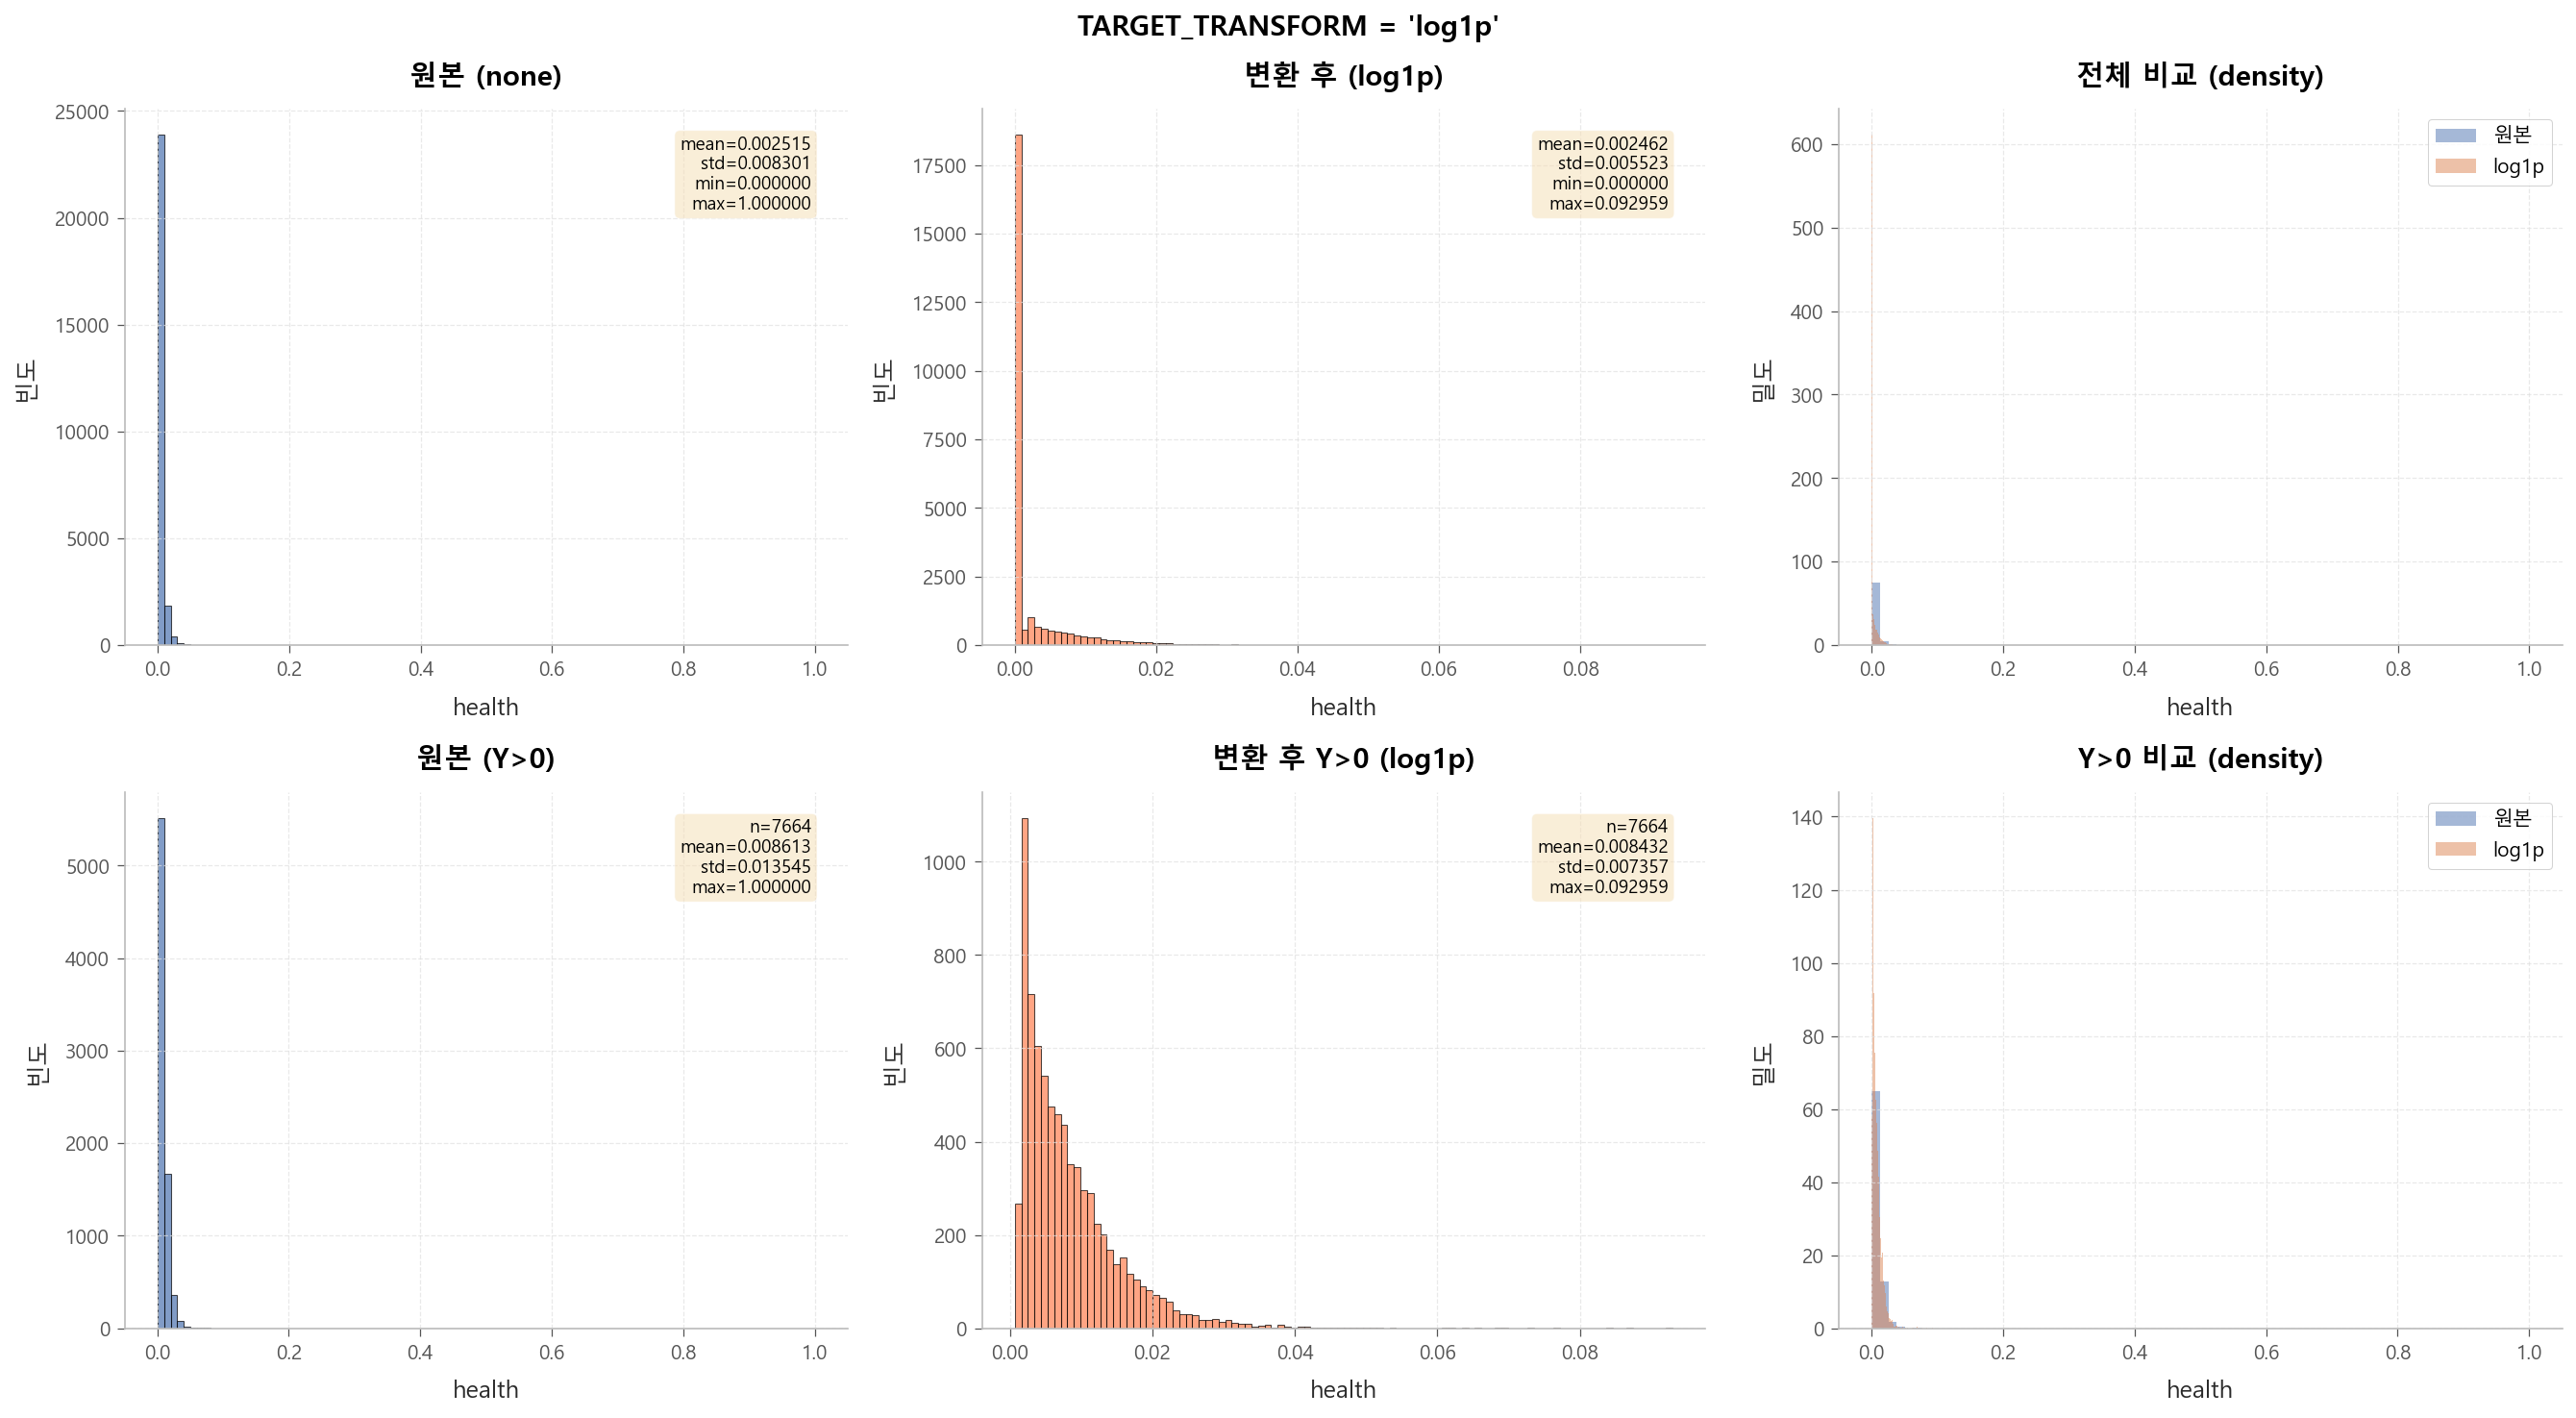

In [4]:
# ── 타깃 변환 (TARGET_TRANSFORM 스위치) ──
# 중요: ys_input 은 항상 **원본 스케일**을 유지한다 (train y만 CLIP_Y_EXTREME 적용).
#       transform/inverse 는 e2e 함수 내부에서 reg fit 직전/예측 직후에만 일어나며,
#       zero_clip/RMSE/val_rmse 등 모든 후처리는 원본 스케일에서 계산된다.
target_transformer = None
target_transform_fn = None
target_inverse_fn = None
ys_input = {k: v.copy() for k, v in ys.items()}

# ── y_train 극단값 클립 (CLIP_Y_EXTREME=True 시) ──
if CLIP_Y_EXTREME:
    _train_y_raw = ys_input['train'][TARGET_COL]
    _second_max = _train_y_raw[_train_y_raw < _train_y_raw.max()].max()
    ys_input['train'][TARGET_COL] = _train_y_raw.clip(upper=_second_max)
    print(f'[CLIP_Y_EXTREME] 1.0 → {_second_max:.6f} 클립 | '
          f'클립된 샘플: {(_train_y_raw >= 1.0).sum()}개')

if TARGET_TRANSFORM == 'log1p':
    target_transform_fn = lambda y: np.log1p(np.asarray(y))
    target_inverse_fn   = lambda y: np.clip(np.expm1(np.asarray(y)), 0.0, None)
    print('[log1p] target_transform_fn 등록 (ys_input 은 원본 유지)')

elif TARGET_TRANSFORM == 'yeo-johnson':
    from sklearn.preprocessing import PowerTransformer
    target_transformer = PowerTransformer(method='yeo-johnson', standardize=False)
    _train_y_clipped = ys_input['train'][TARGET_COL].values.reshape(-1, 1)
    target_transformer.fit(_train_y_clipped)
    _train_y_trans_vals = target_transformer.transform(_train_y_clipped).ravel()
    _tt_min = float(_train_y_trans_vals.min())
    _tt_max = float(_train_y_trans_vals.max())

    def target_transform_fn(y):
        return target_transformer.transform(np.asarray(y).reshape(-1, 1)).ravel()

    def target_inverse_fn(y):
        y_clip = np.clip(np.asarray(y), _tt_min, _tt_max)
        out = target_transformer.inverse_transform(y_clip.reshape(-1, 1)).ravel()
        out = np.clip(out, 0.0, None)
        return np.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0)

    print(f'[yeo-johnson] target_transform_fn 등록 '
          f'(train y 변환 범위: [{_tt_min:.6f}, {_tt_max:.6f}])')

else:  # 'none'
    print('[none] target 변환 없음')

# ── 타깃 변환 전후 분포 시각화 ──
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

y_orig = ys['train'][TARGET_COL]
# ys_input['train'] 은 이제 원본 스케일이므로, 시각화용으로만 on-the-fly 변환
if target_transform_fn is not None:
    y_trans = pd.Series(
        target_transform_fn(ys_input['train'][TARGET_COL].values),
        index=ys_input['train'].index,
    )
else:
    y_trans = ys_input['train'][TARGET_COL]
y_orig_nz = y_orig[y_orig > 0]
y_trans_nz = y_trans[y_trans != y_trans.min()]

# ── 1행: 전체 ──
axes[0, 0].hist(y_orig, bins=100, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('원본 (none)')
axes[0, 0].text(0.95, 0.95, f'mean={y_orig.mean():.6f}\nstd={y_orig.std():.6f}\nmin={y_orig.min():.6f}\nmax={y_orig.max():.6f}',
                transform=axes[0, 0].transAxes, va='top', ha='right', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

axes[0, 1].hist(y_trans, bins=100, edgecolor='black', alpha=0.7, color='coral')
axes[0, 1].set_title(f'변환 후 ({TARGET_TRANSFORM})')
axes[0, 1].text(0.95, 0.95, f'mean={y_trans.mean():.6f}\nstd={y_trans.std():.6f}\nmin={y_trans.min():.6f}\nmax={y_trans.max():.6f}',
                transform=axes[0, 1].transAxes, va='top', ha='right', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

axes[0, 2].hist(y_orig, bins=80, alpha=0.5, label='원본', density=True)
axes[0, 2].hist(y_trans, bins=80, alpha=0.5, label=f'{TARGET_TRANSFORM}', density=True)
axes[0, 2].set_title('전체 비교 (density)')
axes[0, 2].legend()

# ── 2행: Y>0만 ──
axes[1, 0].hist(y_orig_nz, bins=100, edgecolor='black', alpha=0.7)
axes[1, 0].set_title('원본 (Y>0)')
axes[1, 0].text(0.95, 0.95, f'n={len(y_orig_nz)}\nmean={y_orig_nz.mean():.6f}\nstd={y_orig_nz.std():.6f}\nmax={y_orig_nz.max():.6f}',
                transform=axes[1, 0].transAxes, va='top', ha='right', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

axes[1, 1].hist(y_trans_nz, bins=100, edgecolor='black', alpha=0.7, color='coral')
axes[1, 1].set_title(f'변환 후 Y>0 ({TARGET_TRANSFORM})')
axes[1, 1].text(0.95, 0.95, f'n={len(y_trans_nz)}\nmean={y_trans_nz.mean():.6f}\nstd={y_trans_nz.std():.6f}\nmax={y_trans_nz.max():.6f}',
                transform=axes[1, 1].transAxes, va='top', ha='right', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

axes[1, 2].hist(y_orig_nz, bins=80, alpha=0.5, label='원본', density=True)
axes[1, 2].hist(y_trans_nz, bins=80, alpha=0.5, label=f'{TARGET_TRANSFORM}', density=True)
axes[1, 2].set_title('Y>0 비교 (density)')
axes[1, 2].legend()

for ax in axes.flat:
    ax.set_xlabel(TARGET_COL)
    ax.set_ylabel('빈도' if ax in axes[:, :2].flat else '밀도')

fig.suptitle(f'TARGET_TRANSFORM = {TARGET_TRANSFORM!r}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. E2E Optuna HPO 실행

1 Trial = 전처리 → CLF OOF → die→unit 집계 → FS → REG OOF → **OOF RMSE** (val-blind)

In [5]:
# ============================================================

# ── study.user_attrs에 저장할 메타데이터 패키징 ──
study_user_attrs = {
    'exp_id': EXP_ID,
    'exp_type': EXP_TYPE,
    'memo': EXP_MEMO,
    'user': USER,
    'pipeline_config': pipeline_config,
    'e2e_params': e2e_params,
    'rerun_params': rerun_params,
    'sampling_params': sampling_params,
    'label_col': LABEL_COL,
    'exclude_cols': EXCLUDE_COLS,
    'target_transform': TARGET_TRANSFORM,
    'clip_y_extreme': CLIP_Y_EXTREME,
    'preprocessing_search_space': {
        'PP_CLEAN_CANDIDATES':   {k: list(v) for k, v in PP_CLEAN_CANDIDATES.items()},
        'PP_OUTLIER_CANDIDATES': {k: list(v) for k, v in PP_OUTLIER_CANDIDATES.items()},
        'AGG_PRESETS':           [list(p) for p in AGG_PRESETS],
    },
}

result = run_e2e_optimization_with_pp(
    xs=xs,
    xs_dict=xs_dict,
    ys=ys_input,
    feat_cols=feat_cols,
    pipeline_config=pipeline_config,
    label_col=LABEL_COL,
    use_sampling=sampling_params['use_sampling'],
    sample_frac=sampling_params['sample_frac'],
    exclude_cols=EXCLUDE_COLS,
    **e2e_params,
    # 타깃 변환/역변환 (TARGET_TRANSFORM != 'none' 일 때만 유효)
    target_transform_fn=target_transform_fn,
    target_inverse_fn=target_inverse_fn,
    # SQLite / warm start
    exp_id=EXP_ID,
    db_path=DB_PATH,
    study_user_attrs=study_user_attrs,
    warm_start_top_k=30,
    warm_start_enabled=True,
)

study = result['study']
best_params = result['best_params']

print(f'\n── Best Trial ──')
print(f'OOF RMSE (Optuna objective): {result["best_value"]:.6f}')

[Warm Start] 기존 20개 완료 trial 중 상위 20개 enqueue


  0%|          | 0/20 [00:00<?, ?it/s]


E2E + Preprocessing HPO 완료 (20 trials)  [2026-04-15 17:10]
Storage       : c:\Users\Dell5371\Desktop\기업연계프로젝트\4_output\experiments\optuna_jh_3-123-001.db
Study         : 3-123-001
Total trials  : 40 (기존 20 + 신규 20)
PP cache      : 10/10 entries (unique combos)
Best OOF RMSE : 0.005540
Val RMSE (ref): 0.005747
N Features    : clean=675  selected=676
Best agg_funcs: ['std', 'range', 'median']
Zero clip th  : 0.0020
Best trial at : 2026-04-15 15:13

── Best Trial ──
OOF RMSE (Optuna objective): 0.005540


## 5. Best Trial 재실행 (더 많은 Fold)

HPO에서 찾은 best preprocessing + best HP로 더 안정적인 예측을 생성한다.

In [6]:
final = rerun_best_trial_with_pp(
    xs=xs,
    xs_dict=xs_dict,
    ys=ys_input,
    feat_cols=feat_cols,
    best_params=best_params,
    pipeline_config=pipeline_config,
    clf_model=e2e_params['clf_model'],
    reg_model=e2e_params['reg_model'],
    label_col=LABEL_COL,
    imbalance_method=e2e_params['imbalance_method'],
    top_k_fixed=e2e_params['top_k_fixed'],
    clf_filter_threshold_fixed=e2e_params['clf_filter_threshold_fixed'],
    zero_clip_threshold_fixed=e2e_params['zero_clip_threshold_fixed'],
    clf_fixed=e2e_params['clf_fixed'],
    reg_fixed=e2e_params['reg_fixed'],
    target_transform_fn=target_transform_fn,
    target_inverse_fn=target_inverse_fn,
    use_sampling=sampling_params['use_sampling'],
    sample_frac=sampling_params['sample_frac'],
    exclude_cols=EXCLUDE_COLS,
    **rerun_params,
)

# 주의: rerun_best_trial_with_pp 내부에서 reg 예측 직후 이미 역변환 완료.
#       final['val_pred'] / final['test_pred'] / final['oof_pred'] 는 모두 **원본 스케일**이다.

# --- OOF 평가 (핵심 지표) ---
# 정답은 원본 ys에서 직접 가져옴 (클립 전 y 포함)
if rerun_params['mode'] == 'kfold' and 'oof_pred' in final:
    y_train_unit = ys['train'][TARGET_COL].values
    if sampling_params['use_sampling']:
        # 샘플링 시 unit_data에 있는 unit만 매칭
        train_keys = final['unit_data']['train'][KEY_COL].values
        y_train_raw = ys['train'].set_index(KEY_COL).loc[train_keys, TARGET_COL].values
        y_train_unit = y_train_raw
    rerun_oof_rmse = rmse(y_train_unit, final['oof_pred'])
    evaluate(y_train_unit, final['oof_pred'], label='E2E Rerun (OOF)')
    final['oof_rmse'] = float(rerun_oof_rmse)
else:
    rerun_oof_rmse = None

# --- Validation 평가 (EVAL_VAL=True 일 때만 참고용) ---
if EVAL_VAL:
    y_val = ys['validation'][TARGET_COL].values
    evaluate(y_val, final['val_pred'], label='E2E Rerun (val, 참고)')
    final['val_rmse'] = float(rmse(y_val, final['val_pred']))
else:
    print('[val] EVAL_VAL=False → val RMSE 계산 생략')
    final['val_rmse'] = None

# --- Test 평가 (EVAL_TEST=True 일 때만 최종 RMSE 계산) ---
if EVAL_TEST:
    y_test = ys['test'][TARGET_COL].values
    test_rmse_score = rmse(y_test, final['test_pred'])
    evaluate(y_test, final['test_pred'], label='E2E Rerun (test)')
else:
    test_rmse_score = None
    print('[test] EVAL_TEST=False → test RMSE 계산 생략 (test peeking 방지)')

Rerun preprocessing: cleaning=12 args, outlier method=winsorize, agg_funcs=['std', 'range', 'median']
클리닝 파이프라인 시작
원본 feature 수: 1087
[상수/극저분산 제거] threshold=1e-06
  제거: 105개, 잔여: 982개
    컬럼: 1087 → 982 (105개 제거)
    DataFrame: (104988, 986)

[고결측 제거] threshold=50%
  제거: 5개, 잔여: 977개
    컬럼: 982 → 977 (5개 제거)
    DataFrame: (104988, 981)

[중복 컬럼 제거] sample_n=5000
  제거: 26개, 잔여: 951개
    컬럼: 977 → 951 (26개 제거)
    DataFrame: (104988, 955)

[고상관 제거] threshold=0.94, keep_by=target_corr (|target 상관| 우선, 동률이면 std (unit-level merge n=26,247))
  제거: 232개, 잔여: 719개
    컬럼: 951 → 719 (232개 제거)
    DataFrame: (104988, 723)

[공간 보간 imputation] 총 결측: 641,125
  train-only 모드: train 104,988 / 전체 174,980 행
  1단계 (공간 보간, dist<=2.0): 79,479개 채움 → 잔여: 561,646
  2단계 (lot 평균, train 기준): 480,450개 채움 → 잔여: 81,196
  3단계 (train 전체 평균): 81,196개 채움 → 잔여: 0

  [요약] 641,125 → 공간(79,479) → lot(480,450) → 전체(81,196) → 잔여(0)

[고상관 제거] threshold=0.98, keep_by=std (std)
  제거: 0개, 잔여: 719개
    [고상관 제거 2차 / imputation 후

In [7]:
# ============================================================
# RMSE 비교표 : HPO vs Rerun  ×  OOF / Val(참고) / Test
# ============================================================
# - OOF     : K-fold OOF 예측 기반 RMSE (Optuna 최적화 기준)
# - Val     : EVAL_VAL=True일 때만 참고용으로 표시
# - Test    : EVAL_TEST=True일 때만 표시 (test peeking 방지)

# ── HPO best trial ──
hpo_best     = study.best_trial
hpo_oof      = hpo_best.value  # OOF RMSE (Optuna 최적화 기준)
hpo_val_ref  = hpo_best.user_attrs.get('val_rmse', None)
hpo_n_folds  = e2e_params['n_folds']

# ── Rerun ──
rerun_oof  = final.get('oof_rmse', rerun_oof_rmse)
rerun_val  = final.get('val_rmse')
rerun_test = test_rmse_score  # None if EVAL_TEST=False

def _fmt(v, na='—'):
    return f'{v:.6f}' if v is not None else na

hpo_test_str    = '—'
rerun_test_str  = _fmt(rerun_test, 'N/A (EVAL_TEST=False)')
rerun_oof_str   = _fmt(rerun_oof, 'N/A (mode=single)')
rerun_val_str   = _fmt(rerun_val, 'N/A (EVAL_VAL=False)')

hpo_label = f'HPO   ({hpo_n_folds}-fold)'
if rerun_params['mode'] == 'kfold':
    rerun_label = f'Rerun ({rerun_params["n_folds"]}-fold)'
else:
    rerun_label = f'Rerun (single, es_holdout={rerun_params["es_holdout"]})'

# ── 표 출력 ──
LINE = '=' * 78
print(LINE)
print('RMSE 비교표  (Optuna 최적화 기준: OOF RMSE)')
print(LINE)
print(f'{"":22s}  {"OOF":>12s}  {"Val(참고)":>12s}  {"Test":>24s}')
print('-' * 78)
print(f'{hpo_label:22s}  {_fmt(hpo_oof):>12s}  {_fmt(hpo_val_ref):>12s}  {hpo_test_str:>24s}')
print(f'{rerun_label:22s}  {rerun_oof_str:>12s}  {rerun_val_str:>12s}  {rerun_test_str:>24s}')
print(LINE)
print(' ※ OOF = K-fold Out-of-Fold 예측 기반 RMSE (Optuna 최적화 기준)')
print(' ※ Val / Test = K-fold 앙상블 예측 RMSE (참고용, 비공개 데이터)')

RMSE 비교표  (Optuna 최적화 기준: OOF RMSE)
                                 OOF       Val(참고)                      Test
------------------------------------------------------------------------------
HPO   (3-fold)              0.005540      0.005747                         —
Rerun (5-fold)              0.008262      0.005751                  0.008437
 ※ OOF = K-fold Out-of-Fold 예측 기반 RMSE (Optuna 최적화 기준)
 ※ Val / Test = K-fold 앙상블 예측 RMSE (참고용, 비공개 데이터)


## 6. 결과 시각화

In [8]:
# Optuna 결과 시각화
from modules.viz import plot_optuna_results

plot_optuna_results(study, title_prefix="Baseline -- ")


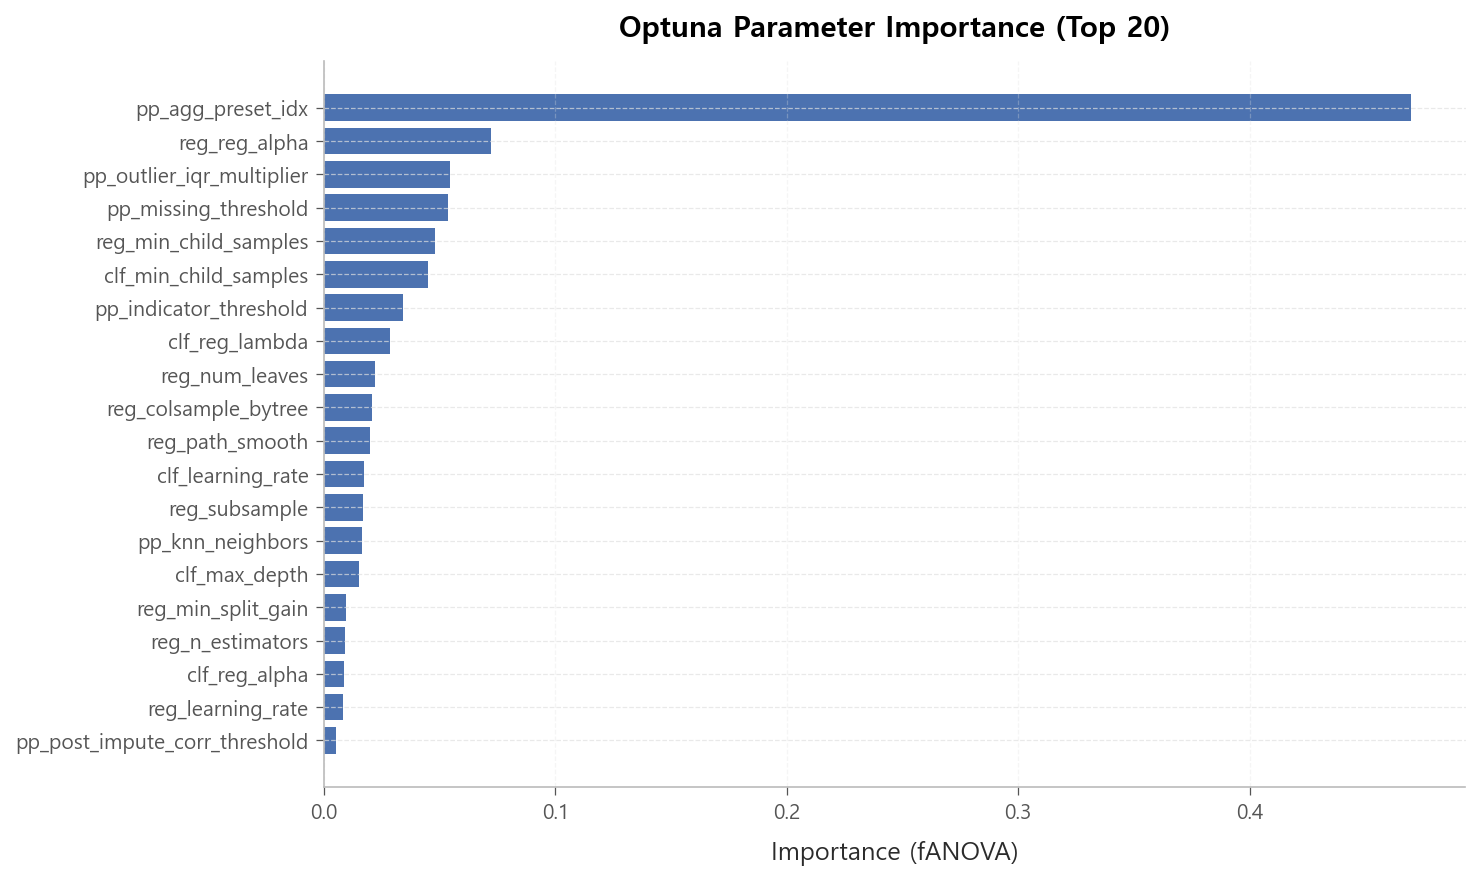


파라미터 중요도 (fANOVA):
  pp_agg_preset_idx                        0.4697
  reg_reg_alpha                            0.0721
  pp_outlier_iqr_multiplier                0.0543
  pp_missing_threshold                     0.0534
  reg_min_child_samples                    0.0479
  clf_min_child_samples                    0.0448
  pp_indicator_threshold                   0.0340
  clf_reg_lambda                           0.0285
  reg_num_leaves                           0.0220
  reg_colsample_bytree                     0.0207
  reg_path_smooth                          0.0200
  clf_learning_rate                        0.0174
  reg_subsample                            0.0169
  pp_knn_neighbors                         0.0165
  clf_max_depth                            0.0153
  reg_min_split_gain                       0.0095
  reg_n_estimators                         0.0093
  clf_reg_alpha                            0.0086
  reg_learning_rate                        0.0080
  pp_post_impute_corr_threshol

In [9]:
# ============================================================
# Optuna 파라미터 중요도 (fANOVA)
# ============================================================
from optuna.importance import get_param_importances, FanovaImportanceEvaluator

param_imp = get_param_importances(
    study,
    evaluator=FanovaImportanceEvaluator(seed=SEED),
)

# 상위 20개 파라미터
top_params = dict(list(param_imp.items())[:20])

fig, ax = plt.subplots(figsize=(10, 6))
names = list(top_params.keys())[::-1]
values = list(top_params.values())[::-1]
ax.barh(names, values)
ax.set_xlabel("Importance (fANOVA)")
ax.set_title(f"Optuna Parameter Importance (Top {len(top_params)})")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

print("\n파라미터 중요도 (fANOVA):")
for k, v in top_params.items():
    print(f"  {k:40s} {v:.4f}")

In [ ]:
# SHAP 분석 -- reg 모델
from modules.viz import plot_shap_analysis

selected_cols = final["selected_cols"]
X_val_arr = final["unit_data"]["val"][selected_cols].values
fold_models = final.get("reg_models", [])
plot_shap_analysis(
    [fold_models[0]] if fold_models else [],
    X_val_arr, selected_cols,
    model_names=["LGBM"],
)


In [ ]:
# Feature Importance -- LGBM gain + permutation
from modules.viz import plot_fi_comparison

# gain
fold_models = final.get('reg_models') or final.get('per_model_fold_models', {}).get('lgbm', [])
if fold_models and hasattr(fold_models[0], 'feature_importances_'):
    selected_cols = final['selected_cols']
    gain = fold_models[0].feature_importances_
    df_imp = pd.DataFrame({'feature': selected_cols, 'lgbm_gain': gain})
    df_imp = df_imp.sort_values('lgbm_gain', ascending=False).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(8, 8))
    top = df_imp.head(20)
    ax.barh(range(20), top['lgbm_gain'].values, color='steelblue')
    ax.set_yticks(range(20))
    ax.set_yticklabels(top['feature'].values, fontsize=9)
    ax.set_title('Top 20: LGBM Gain')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print('fold_models not available for FI')


## 7. 최종 CSV 출력 + Study 저장

- `{EXP_ID}_final_val.csv` / `{EXP_ID}_final_test.csv` — 베스트 trial 예측
- `{EXP_ID}_study.pkl` — trial별 파라미터·val RMSE·user_attrs 전부 (사후 분석용)

In [12]:
import pickle

# ─────────────────────────────────────────────────────────
# 1) Single E2E (rerun 결과) 메트릭/예측 준비
# ─────────────────────────────────────────────────────────
single_oof_rmse  = final.get('oof_rmse')
single_val_rmse  = final.get('val_rmse')
single_test_rmse = float(test_rmse_score) if test_rmse_score is not None else None
single_val_pred  = final['val_pred']
single_test_pred = final['test_pred']
single_key_val   = final['unit_data']['val'][KEY_COL].values
single_key_test  = final['unit_data']['test'][KEY_COL].values

def _fmt_rmse(v, na='N/A'):
    return f'{v:.6f}' if v is not None else na

print(f'★ FINAL: e2e_single (lgbm, preprocessing HPO)')
print(f'  OOF RMSE : {_fmt_rmse(single_oof_rmse)}  (최적화 기준)')
print(f'  Val RMSE : {_fmt_rmse(single_val_rmse, "N/A (EVAL_VAL=False)")}  (참고)')
print(f'  Test RMSE: {_fmt_rmse(single_test_rmse, "N/A (EVAL_TEST=False)")}')

# ─────────────────────────────────────────────────────────
# 2) CSV + Optuna study pickle 저장 (SAVE_OUTPUTS 스위치)
# ─────────────────────────────────────────────────────────
if SAVE_OUTPUTS:
    final_val_path  = os.path.join(OUTPUT_DIR, 'experiments', EXP_SUBDIR, f'{EXP_ID}_final_val.csv')
    final_test_path = os.path.join(OUTPUT_DIR, 'experiments', EXP_SUBDIR, f'{EXP_ID}_final_test.csv')
    pd.DataFrame({KEY_COL: single_key_val,  TARGET_COL: single_val_pred }).to_csv(final_val_path,  index=False)
    pd.DataFrame({KEY_COL: single_key_test, TARGET_COL: single_test_pred}).to_csv(final_test_path, index=False)
    print(f'  → {final_val_path}')
    print(f'  → {final_test_path}')

    study_path = os.path.join(OUTPUT_DIR, 'experiments', EXP_SUBDIR, f'{EXP_ID}_study.pkl')
    with open(study_path, 'wb') as f:
        pickle.dump(study, f)
    print(f'  → {study_path}  ({len(study.trials)} trials)')
else:
    print('  [SAVE_OUTPUTS=False] CSV / study pickle 저장 생략')

★ FINAL: e2e_single (lgbm, preprocessing HPO)
  OOF RMSE : 0.008262  (최적화 기준)
  Val RMSE : 0.005751  (참고)
  Test RMSE: 0.008437
  [SAVE_OUTPUTS=False] CSV / study pickle 저장 생략


## 8. 실험 로그

In [ ]:
# ============================================================
# 실험 로그 — CSV 기록 + SQLite user_attrs 업데이트
# ============================================================
# 재현성 원칙: SQLite(optuna_{USER}.db)에 모든 trial + 메타데이터가 저장됨
# CSV는 팀 공용 성적표 (실험 단위 요약, 로컬만 기록 — Drive 업로드 비활성화)

# ── CSV 기록 (로컬만, Drive 업로드 OFF → Drive 승인 팝업 방지) ──
log_experiment(
    csv_path=EXP_CSV_PATH,
    exp_id=EXP_ID,
    exp_type=EXP_TYPE,
    best_model=f'e2e_single ({e2e_params["reg_model"]})',
    val_rmse=single_val_rmse,
    test_rmse=single_test_rmse,
    n_features=len(final['selected_cols']),
    memo=EXP_MEMO,
    user=USER,
    n_trials=len(study.trials),
)

# ── Rerun 최종 결과를 study.user_attrs에 추가 기록 (SQLite에 즉시 반영) ──
study.set_user_attr('final_method', 'e2e_single')
study.set_user_attr('final_oof_rmse', single_oof_rmse)
study.set_user_attr('final_val_rmse', single_val_rmse)
study.set_user_attr('final_test_rmse', single_test_rmse)
study.set_user_attr('final_best_trial_number', study.best_trial.number)
study.set_user_attr('final_selected_cols', final['selected_cols'])

# ── .db 최종 로컬 PC 다운로드 (브라우저 다운로드, Drive 승인 불필요) ──
from utils.config import ENV
if ENV == 'colab':
    from google.colab import files
    db_size_mb = os.path.getsize(DB_PATH) / 1024 / 1024
    print(f'DB 다운로드 시작: {os.path.basename(DB_PATH)} ({db_size_mb:.1f} MB)')
    files.download(DB_PATH)
    print('DB → 로컬 PC 다운로드 요청 완료 (브라우저 기본 다운로드 폴더 확인)')


실험 기록 완료: 3-123-001
  타입: baseline + HPO | 베스트: e2e_single (lgbm) | user: jh
  Val RMSE:  0.005751
  Test RMSE: 0.008437
  피처수: 676 | n_trials: 40 | 메모: lgbm-only, log1p, y_train clip, val, test 비공개
  csv: c:\Users\Dell5371\Desktop\기업연계프로젝트\4_output\experiments\experiments.csv
